In [1]:
import h5py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from neuralop.models import FNO

# from hypermagnetics import plots
# from hypermagnetics.sources import read_db, configure
file_ext = "eval_single"

In [2]:
def fno_input_converter(
    sources: np.ndarray,
    shape: str = "sphere",
    dim: int = 2,
    lim: int = 3,
    res: int = 32,
):
    """Convert source parameters to FNO input format."""
    m, r0, size = np.split(sources, 3, axis=-1)
    n_sources, _ = r0.shape
    
    grid_x = np.linspace(-lim, lim, res)
    grid_y = np.linspace(-lim, lim, res)
    if dim > 2:
        grid_z = np.linspace(-lim, lim, res)
        grids = np.meshgrid(grid_x, grid_y, grid_z, indexing="xy")
    else:
        grids = np.meshgrid(grid_x, grid_y, indexing="xy")

    grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
    input_data = np.zeros((res**dim, dim))

    for n in range(n_sources):
        if shape == "sphere":
            idx_in = np.where(
                np.linalg.norm(grid - r0[n], axis=1) <= size[n, 0]
            )[0]
        elif shape == "prism":
            idx_in = np.where(
                (np.abs(grid[:, 0] - r0[n, 0]) <= size[n, 0])
                & (np.abs(grid[:, 1] - r0[n, 1]) <= size[n, 1])
            )[0]
        else:
            raise ValueError("Unknown shape")

        input_data[idx_in] += m[n, :dim]

    return input_data

(500, 2, 128, 128)


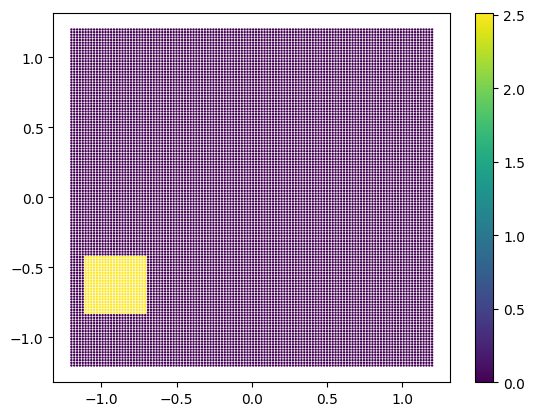

In [37]:
res = 128
batch = 200
res_out = 128 // 4
lim = 1.2
datapath = Path("/home/spol/repos/hypermagnetics/data")

if file_ext == "eval_single":
    batch_size = 500
    db = h5py.File(datapath / "val_eval_large_m_92_1000_1_fno_128.h5", "r")
    input = (
        np.array(db["input"][:batch_size])
        .reshape(batch_size, res, res, -1)
        .transpose(0, 3, 1, 2)
    )
    t_msp = np.array(db["output"][:batch_size]).reshape(
        batch_size, res_out, res_out
    )
else:
    if file_ext == "single":
        sources = np.load(datapath / f"sources_{file_ext}_9_2.npy")
        t_msp = np.load(datapath / f"gt_msp_grid_{file_ext}_9_2.npy")
    elif file_ext == "qt":
        sources = np.load(datapath / f"sources_{file_ext}_0_1.npy")
        t_msp = np.load(datapath / f"gt_msp_grid_{file_ext}_0_1.npy")
    else:
        sources = np.load(datapath / "sources_1_1.npy")
        t_msp = np.load(datapath / "gt_msp_grid_1_1.npy")

    # Check fno function
    input = fno_input_converter(sources, shape="prism", res=res, lim=1.2)

print(input.shape)
grids = np.meshgrid(
            np.linspace(-lim, lim, res),
            np.linspace(-lim, lim, res),
            np.linspace(0, 0, 1),
        )
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res)))
y_grid = np.array(grid[:, 1].reshape((res, res)))

# Plot example
if file_ext == "eval_single":
    idx = 1
    contour = plt.scatter(x_grid, y_grid, c=input[idx, 0].reshape((res, res)), cmap='viridis', s=3, edgecolors='none')
else:
    print(sources.shape)
    contour = plt.scatter(x_grid, y_grid, c=input[..., 0].reshape((res, res)), cmap='viridis', s=3, edgecolors='none')
plt.colorbar(contour)

In [38]:
modelpath = Path("/home/spol/repos/hypermagnetics/models/fno")
modelname = "fno_large_m_128_1M"
model = FNO.from_checkpoint(save_folder=modelpath, save_name=modelname)

if file_ext == "eval_single":
    input = torch.from_numpy(input.astype("float32"))
else:
    input = torch.from_numpy((
        np.array(input[None, :])
        .reshape(1, res, res, -1)
        .transpose(0, 3, 1, 2)).astype(np.float32)
    )
out = model(input).to("cpu").detach().numpy()
out = out.reshape(-1, res_out, res_out)
print(out.shape)

(500, 32, 32)


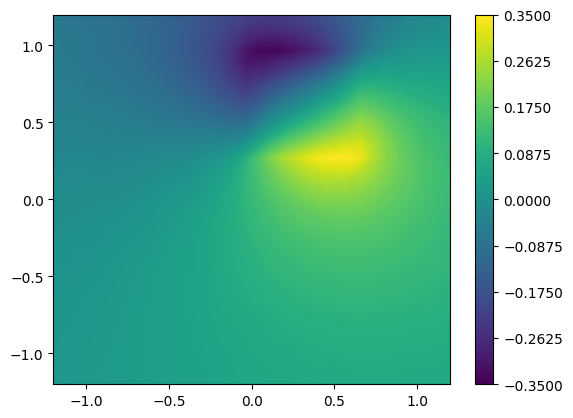

In [54]:
idx = 4
grids = np.meshgrid(
            np.linspace(-lim, lim, res_out),
            np.linspace(-lim, lim, res_out),
            np.linspace(0, 0, 1),
        )
grid_out = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid_out = np.array(grid_out[:, 0].reshape((res_out, res_out)))
y_grid_out = np.array(grid_out[:, 1].reshape((res_out, res_out)))

if file_ext == "single":
    vmax = 2.5 / 10
elif file_ext == "qt":
    vmax = 4.5 / 10
elif file_ext == "eval_single":
    vmax = 3.5 / 10
else:
    vmax = 10 / 10
cbar_ticks = np.linspace(-vmax, vmax, 9)

norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
levels = np.linspace(-vmax, vmax, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid_out, y_grid_out, out[idx] / 10, levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

(500, 32, 32)


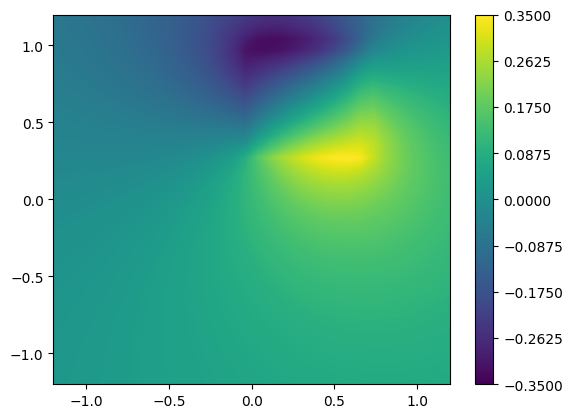

In [55]:
print(t_msp.shape)
if file_ext == "eval_single":
    contour = plt.contourf(x_grid_out, y_grid_out, t_msp[idx] / 10, levels=levels, cmap='viridis', norm=norm)
else:
    contour = plt.contourf(x_grid_out, y_grid_out, np.clip(t_msp / 10, -vmax, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

0.395032


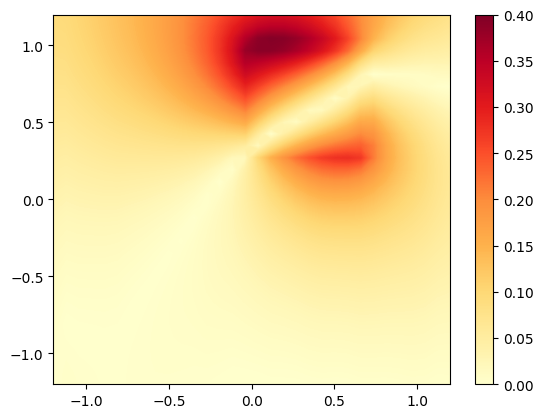

In [59]:
# Error FNO
# pot_strength_gt = np.max(np.abs(t_msp[idx,0]))
# pot_strength_out = np.max(np.abs(out[idx,0]))
# print(pot_strength_gt, pot_strength_out)
# err_fno = (np.abs(np.array(out)[idx,0]  - t_msp[idx]) / np.abs(t_msp[idx])) * 100
err_fno = (np.abs(np.array(out)[idx,0]  - t_msp[idx])) / 10
print(err_fno.max())
vmax_rel = 0.4
vmin_rel = 0

levels_rel = np.linspace(vmin_rel, vmax_rel, 250)
# norm = mcolors.LogNorm(vmin=vmin_rel, vmax=vmax_rel)
contour_rel = plt.contourf(x_grid_out, y_grid_out, np.clip(err_fno, vmin_rel, vmax_rel), cmap="YlOrRd", levels=levels_rel)
cbar = plt.colorbar(contour_rel)
cbar.set_ticks(np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]))

Mean 17.644918
Std 243.04988


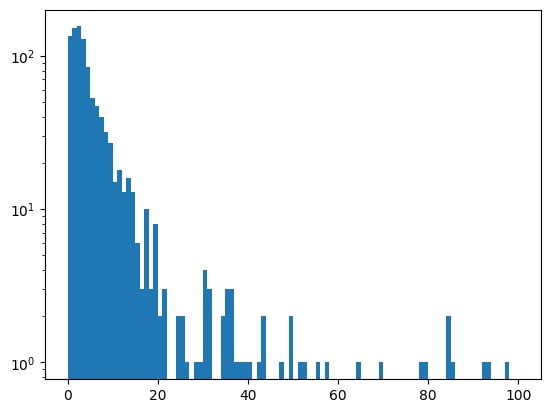

In [60]:
## Error calculation
rel_err_pot = np.abs((t_msp[idx] - np.array(out)[idx]) / t_msp[idx]) * 100
print("Mean", np.mean(rel_err_pot))
print("Std", np.std(rel_err_pot))
plt.hist(rel_err_pot.flatten(), bins=100, range=(0, 100))
plt.yscale("log")

In [ ]:
# Error full dataset
rel_err_pot = np.abs((t_msp - np.array(out)) / t_msp)
m_pot = np.nanmedian(rel_err_pot.reshape((-1, res_out**2)), axis=-1) * 100
print("Mean", np.mean(m_pot))
print("Std", np.std(m_pot))

Mean 56.445995
Std 357.9786
